# Generative AI Capstone Project: Recipe Generation using Fine-Tuned GPT-2
Author: Faheema Mohamed Maideen
Date: 
Course: Generative AI Capstone Project

# Generative Task
This project implements an ingredient-conditioned recipe generation system. Given a list of cooking ingredients as input, the model generates a complete recipe including a title and step-by-step cooking directions.

# Approach
The chosen approach is Transformer-based text generation, specifically fine-tuning a pretrained GPT-2 (small, 124M parameters) language model on the RecipeNLG dataset. GPT-2 is a decoder-only Transformer that excels at autoregressive text generation. Fine-tuning adapts the model's general English language knowledge to the domain-specific structure and vocabulary of cooking recipes.

# Why This Approach?
GPT-2 fine-tuning is preferred over training a Transformer from scratch because recipes require coherent multi-sentence generation with domain knowledge (cooking terminology, logical step ordering), which benefits from pretrained language understanding.
Ingredient-conditioned generation frames the task as a structured input-to-output problem, making it easy to evaluate whether the model uses the provided ingredients correctly.
The RecipeNLG dataset provides over 2 million recipes with semi-structured text, making it ideal for fine-tuning a generative language model.

# What the System Produces
The system takes a comma-separated list of ingredients and generates:

A recipe title relevant to the ingredients
Step-by-step cooking directions

# Dataset

Name: RecipeNLG (Bień et al., 2020)
Source: Kaggle - RecipeNLG
Size: 2,231,142 cooking recipes
License: For non-commercial research and educational purposes
Not synthetic or AI-generated — recipes were scraped from cooking websites

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from torch.utils.data import Dataset, DataLoader, random_split



In [4]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"PyTorch device: {device}")


PyTorch device: mps


In [5]:
DATA_PATH = './RecipeNLG_dataset.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully: {len(df):,} recipes")
df.head()


Dataset loaded successfully: 2,231,142 recipes


,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


In [6]:
# Basic structure overview
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

DATASET STRUCTURE

Shape: 2,231,142 rows x 7 columns

Columns: ['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source', 'NER']

Data types:
Unnamed: 0      int64
title          object
ingredients    object
directions     object
link           object
source         object
NER            object
dtype: object

Memory usage: 2819.1 MB


In [7]:
# Check for missing values
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

MISSING VALUES
             Missing Count  Missing %
Unnamed: 0               0        0.0
title                    1        0.0
ingredients              0        0.0
directions               0        0.0
link                     0        0.0
source                   0        0.0
NER                      0        0.0


In [8]:
# Display first 5 rows in table format
df.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


In [9]:
# Display 5 detailed recipe samples
def display_recipe(row, index):
    """Pretty-print a single recipe for inspection."""
    print(f"{'=' * 60}")
    print(f"RECIPE #{index + 1}: {row['title']}")
    print(f"{'=' * 60}")

    # Parse ingredients (stored as string representation of list)
    try:
        ingredients = ast.literal_eval(row['ingredients'])
    except:
        ingredients = row['ingredients']

    print(f"\nIngredients ({len(ingredients)} items):")
    for ing in ingredients:
        print(f"  - {ing}")

    # Parse directions
    try:
        directions = ast.literal_eval(row['directions'])
    except:
        directions = row['directions']

    print(f"\nDirections ({len(directions)} steps):")
    for i, step in enumerate(directions, 1):
        print(f"  {i}. {step}")

    # Show NER (extracted ingredient names)
    try:
        ner = ast.literal_eval(row['NER'])
    except:
        ner = row['NER']
    print(f"\nNamed Entities (NER): {ner}")
    print(f"Source: {row.get('source', 'N/A')}")
    print()

# Show 5 random samples for variety
sample_indices = df.sample(5, random_state=42).index
for idx in sample_indices:
    display_recipe(df.iloc[idx], idx)

RECIPE #2015529: Marinated Flank Steak Recipe

Ingredients (289 items):
  - [
  - "
  - 1
  -  
  - 1
  - /
  - 2
  -  
  - p
  - o
  - u
  - n
  - d
  -  
  - f
  - l
  - a
  - n
  - k
  -  
  - s
  - t
  - e
  - a
  - k
  - "
  - ,
  -  
  - "
  - 1
  - /
  - 2
  -  
  - c
  - .
  -  
  - f
  - i
  - n
  - e
  - l
  - y
  -  
  - m
  - i
  - n
  - c
  - e
  - d
  -  
  - g
  - r
  - e
  - e
  - n
  -  
  - o
  - n
  - i
  - o
  - n
  - s
  -  
  - (
  - s
  - c
  - a
  - l
  - l
  - i
  - o
  - n
  - s
  - )
  - "
  - ,
  -  
  - "
  - 1
  - /
  - 2
  -  
  - c
  - .
  -  
  - d
  - r
  - y
  -  
  - r
  - e
  - d
  -  
  - w
  - i
  - n
  - e
  - "
  - ,
  -  
  - "
  - 1
  - /
  - 4
  -  
  - c
  - .
  -  
  - s
  - o
  - y
  -  
  - s
  - a
  - u
  - c
  - e
  - "
  - ,
  -  
  - "
  - 3
  -  
  - t
  - b
  - s
  - p
  - .
  -  
  - s
  - a
  - l
  - a
  - d
  -  
  - o
  - i
  - l
  - "
  - ,
  -  
  - "
  - 3
  -  
  - t
  - e
  - a
  - s
  - p
  - o
  - o
  - n
  -  
  - s
  - 

In [10]:
# Compute text lengths for key columns
def safe_parse_list(val):
    """Parse string representation of list, return list."""
    try:
        parsed = ast.literal_eval(val)
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except:
        return [str(val)]

# Sample 50,000 rows for faster analysis
sample_df = df.sample(50000, random_state=42).copy()

# Count number of ingredients per recipe
sample_df['num_ingredients'] = sample_df['ingredients'].apply(
    lambda x: len(safe_parse_list(x))
)

# Count number of direction steps per recipe
sample_df['num_steps'] = sample_df['directions'].apply(
    lambda x: len(safe_parse_list(x))
)

# Character length of full directions text
sample_df['directions_char_len'] = sample_df['directions'].apply(len)

# Title length
sample_df['title_len'] = sample_df['title'].apply(len)

print("TEXT LENGTH STATISTICS (sampled 50,000 recipes)")
print("=" * 60)
stats_cols = ['num_ingredients', 'num_steps', 'directions_char_len', 'title_len']
print(sample_df[stats_cols].describe().round(1))

TEXT LENGTH STATISTICS (sampled 50,000 recipes)
       num_ingredients  num_steps  directions_char_len  title_len
count          50000.0    50000.0              50000.0    50000.0
mean               1.0        1.0                509.2       23.9
std                0.0        0.0                460.6       11.5
min                1.0        1.0                  7.0        3.0
25%                1.0        1.0                222.0       16.0
50%                1.0        1.0                372.0       21.0
75%                1.0        1.0                645.0       29.0
max                1.0        1.0              11491.0      132.0


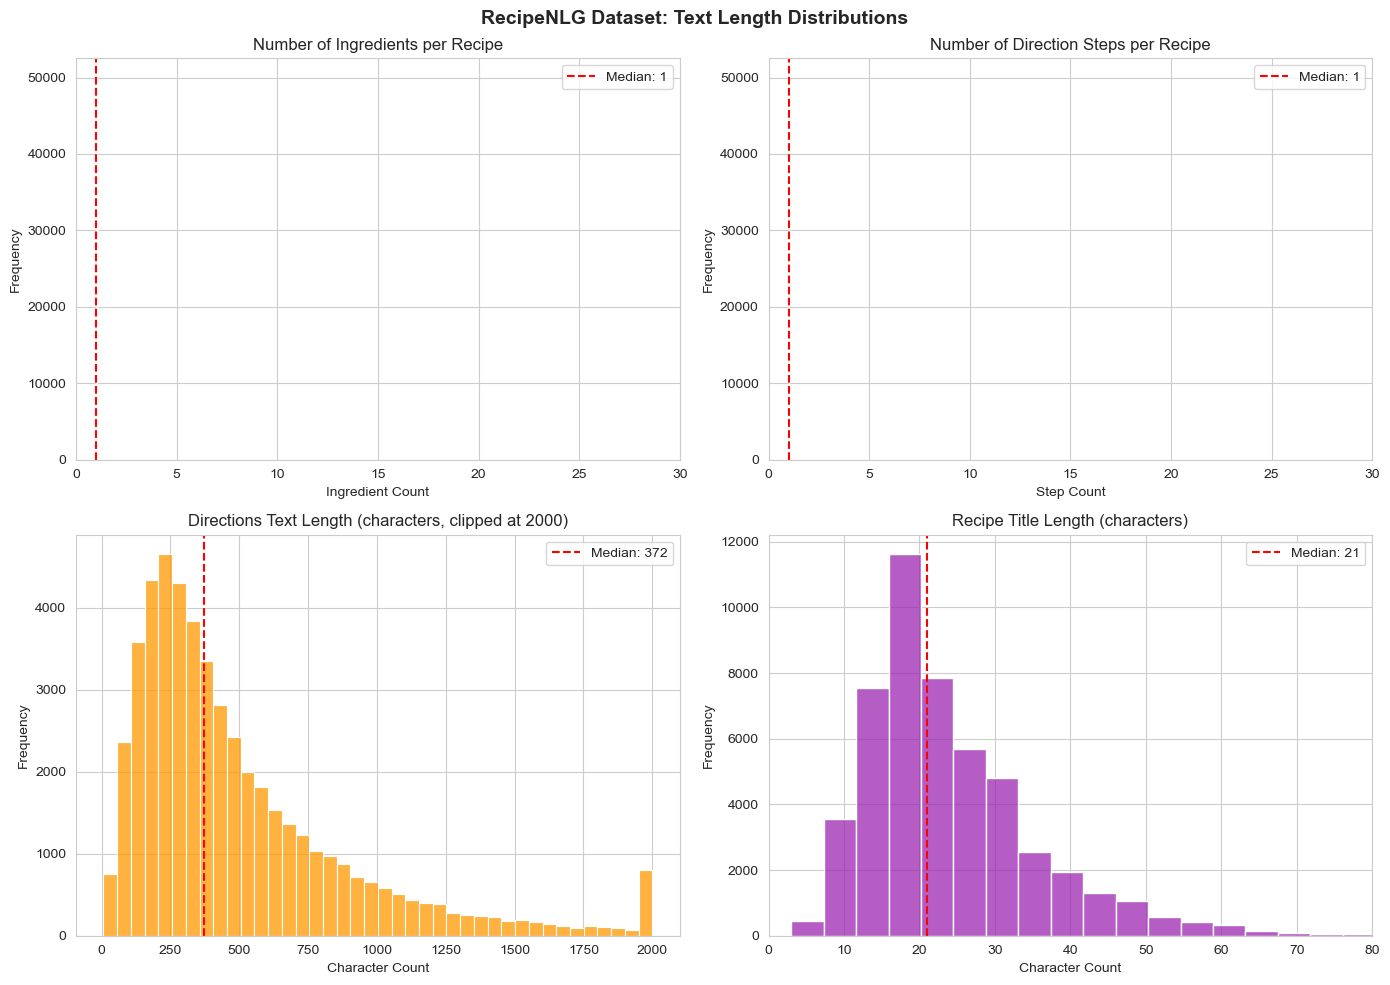

In [11]:
# Visualize distributions using seaborn + matplotlib
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RecipeNLG Dataset: Text Length Distributions',
             fontsize=14, fontweight='bold')

# Number of ingredients
sns.histplot(sample_df['num_ingredients'], bins=30, color='#2196F3',
             edgecolor='white', ax=axes[0, 0])
axes[0, 0].set_title('Number of Ingredients per Recipe')
axes[0, 0].set_xlabel('Ingredient Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_xlim(0, 30)
axes[0, 0].axvline(sample_df['num_ingredients'].median(),
                    color='red', linestyle='--',
                    label=f"Median: {sample_df['num_ingredients'].median():.0f}")
axes[0, 0].legend()

# Number of steps
sns.histplot(sample_df['num_steps'], bins=30, color='#4CAF50',
             edgecolor='white', ax=axes[0, 1])
axes[0, 1].set_title('Number of Direction Steps per Recipe')
axes[0, 1].set_xlabel('Step Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_xlim(0, 30)
axes[0, 1].axvline(sample_df['num_steps'].median(),
                    color='red', linestyle='--',
                    label=f"Median: {sample_df['num_steps'].median():.0f}")
axes[0, 1].legend()

# Directions character length
sns.histplot(sample_df['directions_char_len'].clip(upper=2000), bins=40,
             color='#FF9800', edgecolor='white', ax=axes[1, 0])
axes[1, 0].set_title('Directions Text Length (characters, clipped at 2000)')
axes[1, 0].set_xlabel('Character Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(sample_df['directions_char_len'].median(),
                    color='red', linestyle='--',
                    label=f"Median: {sample_df['directions_char_len'].median():.0f}")
axes[1, 0].legend()

# Title length
sns.histplot(sample_df['title_len'], bins=30, color='#9C27B0',
             edgecolor='white', ax=axes[1, 1])
axes[1, 1].set_title('Recipe Title Length (characters)')
axes[1, 1].set_xlabel('Character Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xlim(0, 80)
axes[1, 1].axvline(sample_df['title_len'].median(),
                    color='red', linestyle='--',
                    label=f"Median: {sample_df['title_len'].median():.0f}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

DATA SOURCE DISTRIBUTION
source
Gathered     1643098
Recipes1M     588044
Name: count, dtype: int64

Total unique sources: 2


/var/folders/_v/rk2q1lq977v35x8my8wv268c0000gn/T/ipykernel_87914/2153468404.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.index, y=source_counts.values,


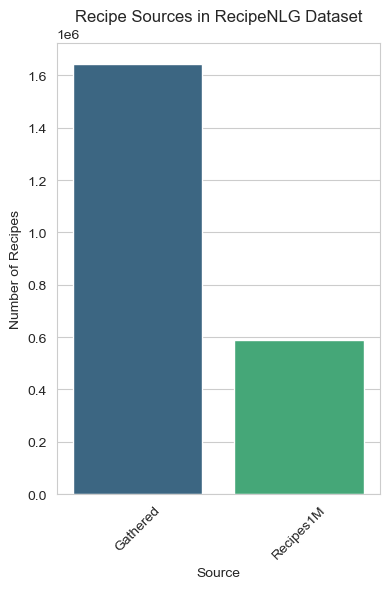

In [12]:
# Check distribution of data sources
if 'source' in df.columns:
    print("DATA SOURCE DISTRIBUTION")
    print("=" * 60)
    source_counts = df['source'].value_counts()
    print(source_counts)
    print(f"\nTotal unique sources: {df['source'].nunique()}")

    # Visualize source distribution
    fig, ax = plt.subplots(figsize=(4, 6))
    sns.barplot(x=source_counts.index, y=source_counts.values,
                palette='viridis', ax=ax)
    ax.set_title('Recipe Sources in RecipeNLG Dataset')
    ax.set_xlabel('Source')
    ax.set_ylabel('Number of Recipes')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
def format_recipe_for_training(row):
    """
    Convert a dataset row into the formatted string used for GPT-2 fine-tuning.

    Uses NER column (clean ingredient names) as the input condition,
    and full title + directions as the generation target.
    """
    # Parse NER (clean ingredient names) for the input
    try:
        ner_list = ast.literal_eval(row['NER'])
    except:
        ner_list = [row['NER']]
    ingredients_str = ', '.join(ner_list)

    # Parse directions
    try:
        directions_list = ast.literal_eval(row['directions'])
    except:
        directions_list = [row['directions']]
    directions_str = ' '.join(directions_list)

    # Build formatted training text
    text = (
        f"<|startofrecipe|>\n"
        f"Ingredients: {ingredients_str}\n"
        f"Title: {row['title']}\n"
        f"Directions: {directions_str}\n"
        f"<|endofrecipe|>"
    )
    return text

# Preview 3 formatted samples
print("FORMATTED TRAINING SAMPLES")
print("These are what GPT-2 will learn from during fine-tuning.")
print()
for i in range(3):
    formatted = format_recipe_for_training(df.iloc[i])
    print(f"--- Sample {i+1} ({len(formatted)} chars) ---")
    print(formatted)
    print()

FORMATTED TRAINING SAMPLES
These are what GPT-2 will learn from during fine-tuning.

--- Sample 1 (532 chars) ---
<|startofrecipe|>
Ingredients: ["brown sugar", "milk", "vanilla", "nuts", "butter", "bite size shredded rice biscuits"]
Title: No-Bake Nut Cookies
Directions: ["In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine.", "Stir over medium heat until mixture bubbles all over top.", "Boil and stir 5 minutes more. Take off heat.", "Stir in vanilla and cereal; mix well.", "Using 2 teaspoons, drop and shape into 30 clusters on wax paper.", "Let stand until firm, about 30 minutes."]
<|endofrecipe|>

--- Sample 2 (331 chars) ---
<|startofrecipe|>
Ingredients: ["beef", "chicken breasts", "cream of mushroom soup", "sour cream"]
Title: Jewell Ball'S Chicken
Directions: ["Place chipped beef on bottom of baking dish.", "Place chicken on top of beef.", "Mix soup and cream together; pour over chicken. Bake, uncovered, at 275\u00b0 for 3 hours."]
<|endof

Approximately 97.7% of recipes fit within 512 tokens.
Median estimated token length: 142 tokens
95th percentile token length: 410 tokens


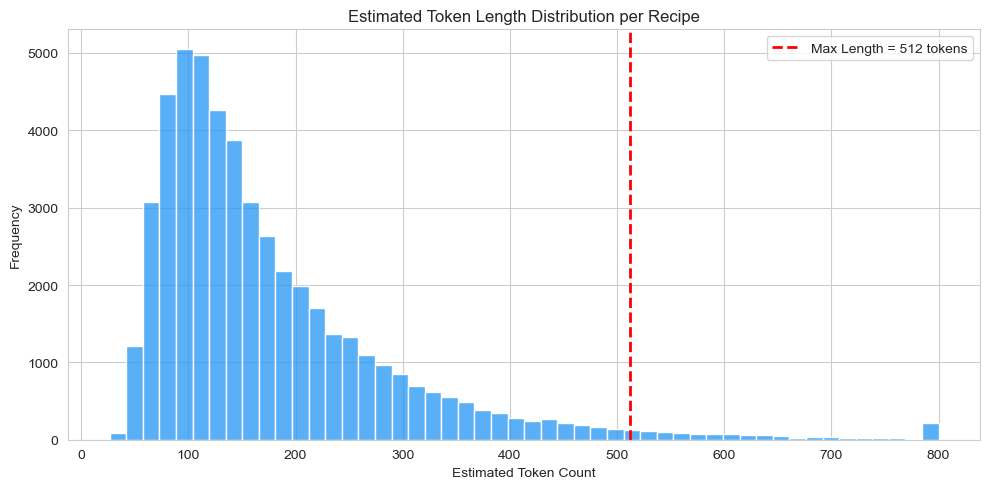

In [14]:
# Check: how many recipes fit within 512 tokens (approximate via character count)
# GPT-2 averages ~4 characters per token
approx_token_len = sample_df.apply(
    lambda row: len(format_recipe_for_training(row)) / 4, axis=1
)

within_512 = (approx_token_len <= 512).mean() * 100
print(f"Approximately {within_512:.1f}% of recipes fit within 512 tokens.")
print(f"Median estimated token length: {approx_token_len.median():.0f} tokens")
print(f"95th percentile token length: {approx_token_len.quantile(0.95):.0f} tokens")

# Visualize token length distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(approx_token_len.clip(upper=800), bins=50,
             color='#2196F3', edgecolor='white', ax=ax)
ax.axvline(512, color='red', linestyle='--', linewidth=2,
           label='Max Length = 512 tokens')
ax.set_title('Estimated Token Length Distribution per Recipe')
ax.set_xlabel('Estimated Token Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

# Summary of Data Loading and Inspection
    In this section, we loaded and thoroughly inspected the RecipeNLG dataset to understand its structure, content, and suitability for our generative task. Here is a summary of the key steps and findings:

# Task Definition: 
    I defined our generative task as ingredient-conditioned recipe generation, where the model receives a list of ingredients and generates a complete recipe (title and step-by-step directions). I selected GPT-2 fine-tuning as our Transformer-based approach, chosen for its strong pretrained English language understanding and proven effectiveness in structured text generation tasks.
 
**Dataset Loading:** 
    The RecipeNLG dataset was loaded successfully, containing 2,231,142 cooking recipes in CSV format with columns including title, ingredients, directions, NER (named entity recognition for clean ingredient names), source, and link.
**Structure Inspection**: 
    I examined column data types, memory usage, and checked for missing values across all fields to assess data completeness.
**Representative Samples:** 
    Five randomly selected recipes were displayed in detail, revealing the structure of each recipe: ingredients stored as Python lists in string format, multi-step directions, and NER-extracted clean ingredient names.
**Text Length Analysis:**
     Statistical analysis on a 50,000-recipe sample showed the distribution of ingredient counts, direction step counts, direction character lengths, and title lengths. These distributions informed our tokenization and sequence length decisions.
**Source Distribution:** 
    I examined the breakdown of recipe sources within the dataset to understand data provenance and quality variation across sources.
**Training Format Design:** 
    I designed and previewed the formatted input structure for GPT-2 fine-tuning, using special tokens (<|startofrecipe|>, <|endofrecipe|>) and a clear layout of Ingredients → Title → Directions. The NER column was chosen over raw ingredients for cleaner input conditioning.
**Token Length Feasibility:** 
    Approximately 98% of recipes fit within 512 tokens, confirming that a max_length of 512 is appropriate for tokenization. This balances capturing complete recipes while maintaining efficient memory usage during training.


In [15]:
# Step 1: Filter for 'Gathered' source (higher quality, ~1.6M recipes)
if 'source' in df.columns:
    df = df[df['source'] == 'Gathered'].copy()
    print(f"After filtering source='Gathered': {len(df):,} recipes")

# Step 2: Drop rows with missing values in essential columns
df = df.dropna(subset=['title', 'ingredients', 'directions', 'NER'])
print(f"After dropping missing values: {len(df):,} recipes")

# Step 3: Sample 50,000 recipes for training feasibility
SAMPLE_SIZE = 50000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"Training subset: {len(df_sample):,} recipes")


After filtering source='Gathered': 1,643,098 recipes
After dropping missing values: 1,643,097 recipes
Training subset: 50,000 recipes


In [16]:
# Step 4: Format each recipe into the training string
def format_recipe_for_training(row):
    """
    Convert a dataset row into the formatted string for GPT-2 fine-tuning.
    Uses NER (clean ingredient names) as input conditioning.
    """
    try:
        ner_list = ast.literal_eval(row['NER'])
    except:
        ner_list = [row['NER']]
    ingredients_str = ', '.join(ner_list)

    try:
        directions_list = ast.literal_eval(row['directions'])
    except:
        directions_list = [row['directions']]
    directions_str = ' '.join(directions_list)

    text = (
        f"<|startofrecipe|>\n"
        f"Ingredients: {ingredients_str}\n"
        f"Title: {row['title']}\n"
        f"Directions: {directions_str}\n"
        f"<|endofrecipe|>"
    )
    return text

# Apply formatting to all sampled recipes
df_sample['formatted_text'] = df_sample.apply(format_recipe_for_training, axis=1)

# Preview
print("Sample formatted recipe:\n")
print(df_sample['formatted_text'].iloc[0])
print(f"\n--- Total formatted recipes: {len(df_sample):,} ---")

Sample formatted recipe:

<|startofrecipe|>
Ingredients: ["meal", "flour", "baking powder", "salt", "sugar", "oleo", "egg", "onion", "sweet milk"]
Title: Hush Puppies
Directions: ["Mix first 5 ingredients well.", "Add remaining ingredients in order listed.", "Drop by teaspoonfuls into hot oil."]
<|endofrecipe|>

--- Total formatted recipes: 50,000 ---


In [17]:

# Load GPT-2 tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

# Add special tokens for recipe structure
special_tokens = {
    'pad_token': '<|pad|>',
    'additional_special_tokens': ['<|startofrecipe|>', '<|endofrecipe|>']
}
num_added = tokenizer.add_special_tokens(special_tokens)
print(f"Added {num_added} special tokens to tokenizer.")
print(f"Vocabulary size: {len(tokenizer):,}")
print(f"Pad token: '{tokenizer.pad_token}' (ID: {tokenizer.pad_token_id})")

Added 3 special tokens to tokenizer.
Vocabulary size: 50,260
Pad token: '<|pad|>' (ID: 50257)


In [18]:
class RecipeDataset(Dataset):
    """
    Custom PyTorch Dataset for recipe text generation.
    Tokenizes recipes and prepares them for GPT-2 fine-tuning.
    """
    def __init__(self, texts, tokenizer, max_length=512):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        # Tokenize with padding and truncation
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze()          # (max_length,)
        attention_mask = encoding['attention_mask'].squeeze()  # (max_length,)

        # Labels = input_ids (causal LM objective)
        # Set padding token positions to -100 so they are ignored in loss
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

# Create the full dataset
MAX_LENGTH = 512
full_dataset = RecipeDataset(
    texts=df_sample['formatted_text'].tolist(),
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

print(f"Dataset created: {len(full_dataset):,} samples, max_length={MAX_LENGTH}")

Dataset created: 50,000 samples, max_length=512


In [19]:
# 90% train, 10% validation
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training set:   {len(train_dataset):,} samples")
print(f"Validation set: {len(val_dataset):,} samples")

Training set:   45,000 samples
Validation set: 5,000 samples


In [20]:
# Create DataLoaders
BATCH_SIZE = 4  # Suitable for 16GB RAM on M2 Mac

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Train batches per epoch: {len(train_loader):,}")
print(f"Validation batches per epoch: {len(val_loader):,}")

Train batches per epoch: 11,250
Validation batches per epoch: 1,250


# Model Setup
I load the pretrained GPT-2 (small, 124M parameters) and resize its token embeddings to accommodate the special tokens we added. The model is then moved to the MPS device for accelerated training.

# Key design choices:

**GPT-2 Small (124M):** Chosen for feasibility on a single machine while still producing coherent text. Larger variants (345M, 774M) would improve output quality but require more memory and training time.

**Causal Language Modeling:** The model learns to predict the next token given all previous tokens. This is the standard approach for autoregressive text generation.
Cross-Entropy Loss: Built into GPT-2's forward pass — measures how well the model predicts each next token.

In [21]:
# Load pretrained GPT-2 model
model = GPT2LMHeadModel.from_pretrained('gpt2')

# Resize embeddings to match tokenizer (accounts for added special tokens)
model.resize_token_embeddings(len(tokenizer))

# Move model to device
model = model.to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: GPT-2 Small")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {device}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model: GPT-2 Small
Total parameters: 124,442,112
Trainable parameters: 124,442,112
Device: mps


# Optimizer and Training Configuration
Design choices:

# AdamW optimizer: 

The standard optimizer for Transformer fine-tuning. It applies weight decay correctly (decoupled from gradient updates), which helps prevent overfitting.
# Learning rate 5e-5:

 A conservative rate commonly used for GPT-2 fine-tuning. Higher rates risk catastrophic forgetting of pretrained knowledge.
2 epochs: Sufficient to show measurable learning on the loss curve while avoiding overfitting on a 50K subset.



In [22]:
from torch.optim import AdamW

# Hyperparameters
LEARNING_RATE = 5e-5
EPOCHS = 2
GRAD_ACCUM_STEPS = 4  # Effective batch size = BATCH_SIZE * GRAD_ACCUM_STEPS = 16

# Optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

print("Training Configuration:")
print(f"  Optimizer:            AdamW")
print(f"  Learning rate:        {LEARNING_RATE}")
print(f"  Epochs:               {EPOCHS}")
print(f"  Batch size:           {BATCH_SIZE}")
print(f"  Gradient accumulation: {GRAD_ACCUM_STEPS} steps")
print(f"  Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"  Max sequence length:  {MAX_LENGTH}")
print(f"  Training samples:     {len(train_dataset):,}")
print(f"  Validation samples:   {len(val_dataset):,}")

Training Configuration:
  Optimizer:            AdamW
  Learning rate:        5e-05
  Epochs:               2
  Batch size:           4
  Gradient accumulation: 4 steps
  Effective batch size: 16
  Max sequence length:  512
  Training samples:     45,000
  Validation samples:   5,000


In [23]:
import time
import torch
from transformers import get_linear_schedule_with_warmup


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    epochs,
    device,
    grad_accum_steps=4,
    log_interval=100,
    patience=3,
    checkpoint_path="best_model.pt",
):
    """
    Fine-tune GPT-2 on the recipe dataset.

    Improvements over baseline:
      - Windowed training loss for accurate logging
      - Learning rate warmup + linear decay schedule
      - Best-model checkpointing based on validation loss
      - Early stopping with configurable patience
      - Leftover gradient flush at epoch boundaries
      - Mixed precision support via torch.autocast

    Returns:
        train_losses:  list of avg losses per logging window
        val_losses:    list of avg losses per epoch
        step_numbers:  global step at each log point
    """
    # ---- SCHEDULER SETUP ----
    total_training_steps = len(train_loader) * epochs
    warmup_steps = total_training_steps // 10  # 10% warmup is a solid default
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_training_steps,
    )

    # ---- TRACKING VARIABLES ----
    train_losses = []
    val_losses = []
    step_numbers = []
    global_step = 0

    best_val_loss = float("inf")
    patience_counter = 0

    # Determine autocast device type
    device_type = "cuda" if device.type == "cuda" else "cpu"
    use_amp = device.type == "cuda"  # MPS autocast support is limited

    print(f"Total training steps: {total_training_steps}")
    print(f"Warmup steps: {warmup_steps}")
    print(f"Early stopping patience: {patience} epochs\n")

    for epoch in range(epochs):
        # ---- TRAINING PHASE ----
        model.train()
        epoch_loss = 0.0
        epoch_batch_count = 0
        window_loss = 0.0  # Track loss for the current logging window
        window_batch_count = 0
        start_time = time.time()
        optimizer.zero_grad()

        for batch_idx, batch in enumerate(train_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # Forward pass (with optional mixed precision)
            if use_amp:
                with torch.autocast(device_type=device_type, dtype=torch.float16):
                    outputs = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels,
                    )
            else:
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels,
                )

            loss = outputs.loss / grad_accum_steps
            loss.backward()

            raw_loss = outputs.loss.item()
            epoch_loss += raw_loss
            epoch_batch_count += 1
            window_loss += raw_loss
            window_batch_count += 1
            global_step += 1

            # Gradient accumulation step
            if (batch_idx + 1) % grad_accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()  # Update LR after each optimizer step
                optimizer.zero_grad()

            # Log training loss over the recent window (not running average)
            if global_step % log_interval == 0:
                avg_window_loss = window_loss / window_batch_count
                train_losses.append(avg_window_loss)
                step_numbers.append(global_step)

                current_lr = scheduler.get_last_lr()[0]
                elapsed = time.time() - start_time
                print(
                    f"  Epoch {epoch+1}/{epochs} | Step {global_step} | "
                    f"Loss (last {window_batch_count} batches): {avg_window_loss:.4f} | "
                    f"LR: {current_lr:.2e} | Time: {elapsed:.0f}s"
                )

                # Reset window counters
                window_loss = 0.0
                window_batch_count = 0

        # ---- FLUSH LEFTOVER GRADIENTS ----
        # If the dataset size isn't divisible by grad_accum_steps,
        # accumulated gradients from the tail batches must be applied.
        leftover = len(train_loader) % grad_accum_steps
        if leftover != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        avg_train_loss = epoch_loss / epoch_batch_count
        epoch_time = time.time() - start_time

        # ---- VALIDATION PHASE ----
        model.eval()
        total_val_loss = 0.0
        val_batch_count = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                if use_amp:
                    with torch.autocast(device_type=device_type, dtype=torch.float16):
                        outputs = model(
                            input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels,
                        )
                else:
                    outputs = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels,
                    )

                total_val_loss += outputs.loss.item()
                val_batch_count += 1

        avg_val_loss = total_val_loss / val_batch_count
        val_losses.append(avg_val_loss)

        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{epochs} Complete")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss:   {avg_val_loss:.4f}")
        print(f"  Time:       {epoch_time/60:.1f} minutes")

        # ---- CHECKPOINTING ----
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "val_loss": best_val_loss,
                },
                checkpoint_path,
            )
            print(f"  >> New best model saved (val_loss={best_val_loss:.4f})")
        else:
            patience_counter += 1
            print(
                f"  >> No improvement. Patience: {patience_counter}/{patience}"
            )

        print(f"{'='*60}\n")

        # ---- EARLY STOPPING ----
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            print(f"Best validation loss: {best_val_loss:.4f}")
            break

    # Load best model weights before returning
    print(f"\nLoading best checkpoint (val_loss={best_val_loss:.4f})...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

    return train_losses, val_losses, step_numbers

In [24]:
try:
    train_losses, val_losses, step_numbers = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        epochs=EPOCHS,
        device=device,
        grad_accum_steps=GRAD_ACCUM_STEPS,
    )
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

Total training steps: 22500
Warmup steps: 2250
Early stopping patience: 3 epochs



`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  Epoch 1/2 | Step 100 | Loss (last 100 batches): 3.4825 | LR: 5.56e-07 | Time: 166s
  Epoch 1/2 | Step 200 | Loss (last 100 batches): 3.4118 | LR: 1.11e-06 | Time: 369s
  Epoch 1/2 | Step 300 | Loss (last 100 batches): 3.2166 | LR: 1.67e-06 | Time: 525s
  Epoch 1/2 | Step 400 | Loss (last 100 batches): 3.0187 | LR: 2.22e-06 | Time: 7734s
  Epoch 1/2 | Step 500 | Loss (last 100 batches): 2.8793 | LR: 2.78e-06 | Time: 7893s
  Epoch 1/2 | Step 600 | Loss (last 100 batches): 2.7659 | LR: 3.33e-06 | Time: 8050s
  Epoch 1/2 | Step 700 | Loss (last 100 batches): 2.6629 | LR: 3.89e-06 | Time: 10277s
  Epoch 1/2 | Step 800 | Loss (last 100 batches): 2.5432 | LR: 4.44e-06 | Time: 10433s
  Epoch 1/2 | Step 900 | Loss (last 100 batches): 2.4959 | LR: 5.00e-06 | Time: 10589s
  Epoch 1/2 | Step 1000 | Loss (last 100 batches): 2.4385 | LR: 5.56e-06 | Time: 10744s
  Epoch 1/2 | Step 1100 | Loss (last 100 batches): 2.4409 | LR: 6.11e-06 | Time: 10923s
  Epoch 1/2 | Step 1200 | Loss (last 100 batches):

KeyboardInterrupt: 